# 05 — Dashboard BI (Atelier 3)

Dashboard exploitant le **star schema** (6 dimensions + `fact_player_game`).

**Contenu :**
- 3 KPIs simples (agregations globales)
- 4 mesures croisees avec graphiques
- 2 filtres interactifs : `event_tier` et `event_region_name` (ipywidgets)
- Export CSV des donnees filtrees

**Prerequis :** avoir execute les notebooks 01 a 04 (ou `uv run python -m src.etl`).

## 1. Connexion et imports

In [1]:
import sys
from pathlib import Path

# Ensure project root is on sys.path (needed when running via nbconvert)
PROJECT_ROOT = str(Path.cwd().parent) if Path.cwd().name == "notebooks" else str(Path.cwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display, HTML
from sqlalchemy import text

from src.database.engine import engine
from src.config import DATA_DIR

%matplotlib inline
sns.set_theme(style="whitegrid")
EXPORT_DIR = DATA_DIR / "exports"
EXPORT_DIR.mkdir(exist_ok=True)

print("Connexion OK :", engine.url)

Connexion OK : duckdb:///C:\Users\samue\Desktop\Ecoles\EPSI\M1\Cours\Datamart\data\rl.duckdb


## 2. KPIs simples (agregations globales)

3 indicateurs calcules une seule fois sur l'ensemble des donnees.

In [2]:
# KPI 1 : Taux d'overtime
kpi_ot = pd.read_sql(
    "SELECT ROUND(100.0 * SUM(CASE WHEN overtime THEN 1 ELSE 0 END) / COUNT(*), 1) AS overtime_rate "
    "FROM (SELECT DISTINCT game_id, overtime FROM fact_player_game)",
    engine,
)

# KPI 2 : Score moyen par joueur par game
kpi_score = pd.read_sql(
    "SELECT ROUND(AVG(core_score), 1) AS avg_score FROM fact_player_game",
    engine,
)

# KPI 3 : Nombre total de games
kpi_games = pd.read_sql(
    "SELECT COUNT(DISTINCT game_id) AS total_games FROM fact_player_game",
    engine,
)

overtime_rate = kpi_ot["overtime_rate"].iloc[0]
avg_score = kpi_score["avg_score"].iloc[0]
total_games = int(kpi_games["total_games"].iloc[0])

display(HTML(
    '<div style="display:flex; gap:40px; margin:20px 0;">'
    f'<div style="text-align:center; padding:20px; background:#f0f4ff; border-radius:12px; min-width:180px;">'
    f'<div style="font-size:2em; font-weight:bold; color:#2563eb;">{overtime_rate} %</div>'
    f'<div style="color:#555;">Taux d\'overtime</div></div>'
    f'<div style="text-align:center; padding:20px; background:#f0fdf4; border-radius:12px; min-width:180px;">'
    f'<div style="font-size:2em; font-weight:bold; color:#16a34a;">{avg_score}</div>'
    f'<div style="color:#555;">Score moyen / joueur / game</div></div>'
    f'<div style="text-align:center; padding:20px; background:#fef9f0; border-radius:12px; min-width:180px;">'
    f'<div style="font-size:2em; font-weight:bold; color:#d97706;">{total_games:,}</div>'
    f'<div style="color:#555;">Games jouees</div></div>'
    '</div>'
))

print(f"Taux d'overtime : {overtime_rate} %")
print(f"Score moyen : {avg_score} pts")
print(f"Games jouees : {total_games:,}")

Taux d'overtime : 21.0 %
Score moyen : 365.3 pts
Games jouees : 17,797


## 3. Chargement des donnees

Requete principale joignant la table de faits aux dimensions.

In [3]:
def query_data(tier: str = "All", region: str = "All") -> pd.DataFrame:
    """Charge les donnees filtrees depuis le star schema."""
    sql = text(
        "SELECT f.game_id, f.player_id, f.winner, f.color, f.game_duration, f.overtime, "
        "       f.core_score, f.core_goals, f.core_shots, f.core_saves, f.core_assists, "
        "       f.advanced_rating, "
        "       dc.car_name, dm.map_name, "
        "       dd.full_date, dd.year, dd.month, "
        "       de.event_tier, de.event_name, de.event_region_name, "
        "       dp.player_tag "
        "FROM fact_player_game f "
        "JOIN dim_car dc ON f.car_key = dc.car_key "
        "JOIN dim_map dm ON f.map_key = dm.map_key "
        "JOIN dim_date dd ON f.date_key = dd.date_key "
        "JOIN dim_event de ON f.event_key = de.event_key "
        "JOIN dim_player dp ON f.player_key = dp.player_key "
        "WHERE (:tier = 'All' OR de.event_tier = :tier) "
        "  AND (:region = 'All' OR de.event_region_name = :region)"
    )
    return pd.read_sql(sql, engine, params={"tier": tier, "region": region})


# Chargement initial (sans filtre)
df = query_data()
print(f"Donnees chargees : {len(df):,} lignes, {len(df.columns)} colonnes")

Donnees chargees : 105,598 lignes, 21 colonnes


## 4. Graphiques croises (vue par defaut)

4 visualisations rendues directement. La section 5 permet de les re-generer avec des filtres.

105,598 lignes — tier=All, region=All


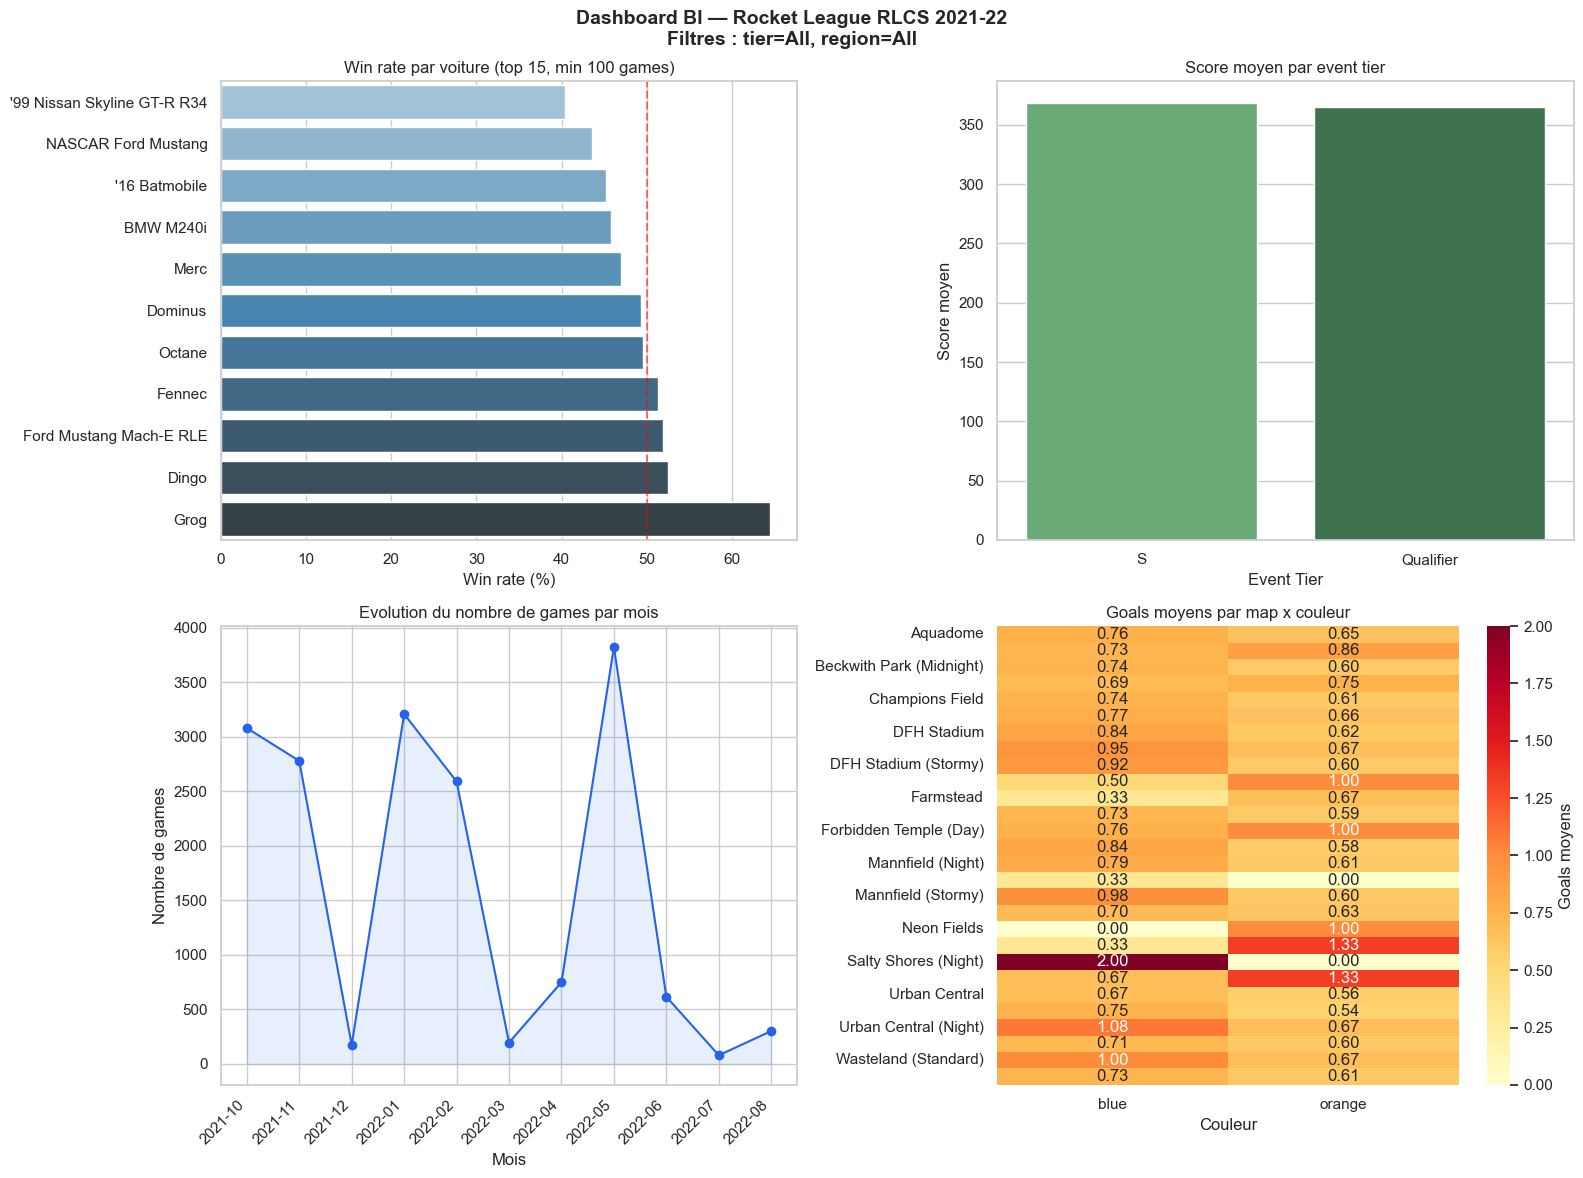

In [4]:
def render_dashboard(df: pd.DataFrame, tier: str = "All", region: str = "All"):
    """Dessine les 4 graphiques croises."""
    if df.empty:
        print("Aucune donnee pour ces filtres.")
        return

    print(f"{len(df):,} lignes — tier={tier}, region={region}")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(
        f"Dashboard BI — Rocket League RLCS 2021-22\n"
        f"Filtres : tier={tier}, region={region}",
        fontsize=14, fontweight="bold",
    )

    # -- 4a. Win rate par voiture (barh, top 15, min 100 games) --
    ax = axes[0, 0]
    car_stats = (
        df.groupby("car_name")
        .agg(games=("winner", "count"), wins=("winner", "sum"))
        .query("games >= 100")
        .assign(win_rate=lambda x: 100.0 * x["wins"] / x["games"])
        .sort_values("win_rate", ascending=True)
        .tail(15)
        .reset_index()
    )
    if not car_stats.empty:
        sns.barplot(
            x="win_rate", y="car_name", hue="car_name", data=car_stats,
            palette="Blues_d", ax=ax, orient="h", legend=False,
        )
        ax.set_xlabel("Win rate (%)")
        ax.set_ylabel("")
        ax.set_title("Win rate par voiture (top 15, min 100 games)")
        ax.axvline(50, color="red", linestyle="--", alpha=0.5)
    else:
        ax.text(0.5, 0.5, "Pas assez de donnees\n(min 100 games/voiture)", ha="center", va="center", transform=ax.transAxes)
        ax.set_title("Win rate par voiture")

    # -- 4b. Score moyen par event tier (bar vertical) --
    ax = axes[0, 1]
    tier_stats = (
        df[df["event_tier"].notna()]
        .groupby("event_tier")["core_score"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )
    if not tier_stats.empty:
        sns.barplot(
            x="event_tier", y="core_score", hue="event_tier", data=tier_stats,
            palette="Greens_d", ax=ax, legend=False,
        )
        ax.set_xlabel("Event Tier")
        ax.set_ylabel("Score moyen")
        ax.set_title("Score moyen par event tier")
    else:
        ax.text(0.5, 0.5, "Pas de donnees", ha="center", va="center", transform=ax.transAxes)
        ax.set_title("Score moyen par event tier")

    # -- 4c. Nombre de games par mois (line chart) --
    ax = axes[1, 0]
    df_dated = df.dropna(subset=["year", "month"]).copy()
    if not df_dated.empty:
        df_dated["year_month"] = (
            df_dated["year"].astype(int).astype(str)
            + "-"
            + df_dated["month"].astype(int).astype(str).str.zfill(2)
        )
        monthly = (
            df_dated.groupby("year_month")["game_id"]
            .nunique()
            .sort_index()
            .reset_index()
            .rename(columns={"game_id": "games"})
        )
        ax.plot(monthly["year_month"], monthly["games"], marker="o", color="#2563eb")
        ax.fill_between(range(len(monthly)), monthly["games"], alpha=0.1, color="#2563eb")
        ax.set_xticks(range(len(monthly)))
        ax.set_xticklabels(monthly["year_month"], rotation=45, ha="right")
        ax.set_xlabel("Mois")
        ax.set_ylabel("Nombre de games")
        ax.set_title("Evolution du nombre de games par mois")
    else:
        ax.text(0.5, 0.5, "Pas de dates", ha="center", va="center", transform=ax.transAxes)
        ax.set_title("Games par mois")

    # -- 4d. Heatmap goals moyens par map x couleur --
    ax = axes[1, 1]
    goals_pivot = (
        df[df["color"].isin(["blue", "orange"])]
        .groupby(["map_name", "color"])["core_goals"]
        .mean()
        .unstack(fill_value=0)
    )
    if not goals_pivot.empty and goals_pivot.shape[1] > 0:
        sns.heatmap(
            goals_pivot, annot=True, fmt=".2f", cmap="YlOrRd",
            ax=ax, cbar_kws={"label": "Goals moyens"},
        )
        ax.set_xlabel("Couleur")
        ax.set_ylabel("")
        ax.set_title("Goals moyens par map x couleur")
    else:
        ax.text(0.5, 0.5, "Pas de donnees", ha="center", va="center", transform=ax.transAxes)
        ax.set_title("Goals par map x couleur")

    plt.tight_layout()
    plt.show()


# Rendu initial (toutes donnees, sans filtre)
render_dashboard(df)

## 5. Filtres interactifs (ipywidgets)

2 dropdowns interactifs : **event_tier** et **event_region_name**.
Changer une valeur re-dessine automatiquement les 4 graphiques.
Bouton **Exporter CSV** pour sauvegarder les donnees filtrees.

> **Note :** les widgets ipywidgets necessitent un environnement Jupyter interactif (Jupyter Notebook, JupyterLab). Ils ne s'affichent pas dans un rendu statique (nbconvert, VS Code preview).

In [5]:
import ipywidgets as widgets

# -- Options des filtres (depuis la base) --
_tiers = pd.read_sql(
    "SELECT DISTINCT event_tier FROM dim_event WHERE event_tier IS NOT NULL ORDER BY event_tier",
    engine,
)
_regions = pd.read_sql(
    "SELECT DISTINCT event_region_name FROM dim_event WHERE event_region_name IS NOT NULL ORDER BY event_region_name",
    engine,
)

dropdown_tier = widgets.Dropdown(
    options=["All"] + _tiers["event_tier"].tolist(),
    value="All",
    description="Event Tier:",
)
dropdown_region = widgets.Dropdown(
    options=["All"] + _regions["event_region_name"].tolist(),
    value="All",
    description="Region:",
)
btn_export = widgets.Button(description="Exporter CSV", button_style="success", icon="download")
output = widgets.Output()


def _update_dashboard(_=None):
    """Re-charge les donnees filtrees et re-dessine les graphiques."""
    output.clear_output(wait=True)
    with output:
        filtered = query_data(tier=dropdown_tier.value, region=dropdown_region.value)
        render_dashboard(filtered, dropdown_tier.value, dropdown_region.value)


def _on_export_click(_):
    """Exporte les donnees filtrees en CSV."""
    with output:
        filtered = query_data(tier=dropdown_tier.value, region=dropdown_region.value)
        path = EXPORT_DIR / "dashboard_export.csv"
        filtered.to_csv(path, index=False)
        print(f"\nExport CSV OK : {path} ({len(filtered):,} lignes)")


dropdown_tier.observe(_update_dashboard, names="value")
dropdown_region.observe(_update_dashboard, names="value")
btn_export.on_click(_on_export_click)

display(widgets.HBox([dropdown_tier, dropdown_region, btn_export]))
_update_dashboard()
display(output)

Output()

## 6. Export CSV (alternative)

Export direct du DataFrame initial vers `data/exports/dashboard_export.csv`.
Pour exporter les donnees **filtrees**, utiliser le bouton "Exporter CSV" de la section 5.

In [6]:
export_path = EXPORT_DIR / "dashboard_export.csv"
df.to_csv(export_path, index=False)

print(f"Export OK : {export_path}")
print(f"{len(df):,} lignes, {len(df.columns)} colonnes")
df.head()

Export OK : C:\Users\samue\Desktop\Ecoles\EPSI\M1\Cours\Datamart\data\exports\dashboard_export.csv
105,598 lignes, 21 colonnes


,game_id,player_id,winner,color,game_duration,overtime,core_score,core_goals,core_shots,core_saves,...,advanced_rating,car_name,map_name,full_date,year,month,event_tier,event_name,event_region_name,player_tag
0,617c8eeff8090ec745289e87,5f3d8fdd95f40596eae2413b,False,blue,693.0,True,761.0,2.0,3.0,3.0,...,1.782523,Dominus,Mannfield (Night),2021-10-29,2021,10,Qualifier,Regional 2,NORTH AMERICA,Jordan
1,617f2cc9f8090ec74528a317,5f3d8fdd95f40596eae23dba,True,blue,300.0,False,695.0,3.0,4.0,3.0,...,2.074398,Octane,Utopia Coliseum (Dusk),2021-10-31,2021,10,Qualifier,Regional 2,NORTH AMERICA,Chicago
2,6180161a143c37878b23be0e,5f3d8fdd95f40596eae24339,True,blue,300.0,False,422.0,2.0,2.0,0.0,...,1.797714,Octane,DFH Stadium,2021-10-31,2021,10,Qualifier,Regional 2,SOUTH AMERICA,Bemmz
3,61864c78f8090ec74528b0c8,5f3d8fdd95f40596eae23ef5,True,blue,300.0,False,227.0,0.0,4.0,2.0,...,0.477351,Fennec,DFH Stadium,2021-11-05,2021,11,Qualifier,Regional 2,ASIA-PACIFIC NORTH,ReaLize
4,618653a3f8090ec74528b1e0,5f3d8fdd95f40596eae23f7d,True,orange,539.0,True,500.0,1.0,1.0,1.0,...,1.376817,Fennec,Mannfield (Night),2021-11-05,2021,11,Qualifier,Regional 2,EUROPE,Breezi


## 7. Resume

| # | KPI | Type |
|---|-----|------|
| 1 | Taux d'overtime | Agregation simple |
| 2 | Score moyen par joueur | Agregation simple |
| 3 | Nombre total de games | Agregation simple |
| 4 | Win rate par voiture | Mesure croisee (barh) |
| 5 | Score moyen par event tier | Mesure croisee (bar) |
| 6 | Games par mois | Mesure croisee (line) |
| 7 | Goals moyens par map x couleur | Mesure croisee (heatmap) |

**Filtres interactifs (ipywidgets) :** `event_tier` + `event_region_name` — dropdowns dans la section 5.

**Export CSV :** bouton dans la section 5, ou executer la section 6 → `data/exports/dashboard_export.csv`.